In [5]:
import pandas as  pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [6]:
df=pd.read_csv("Chernobyl_ Chemical_Radiation (1).csv")
df

,PAYS,Code,Location,Longitude,Latitude,Date,I_131_(Bq/m3),Cs_134_(Bq/m3),Cs_137_(Bq/m3)
0,SE,1,RISOE,12.07,55.7,86/04/27,1,0,0.24
1,SE,1,RISOE,12.07,55.7,86/04/28,0.0046,0.00054,0.00098
2,SE,1,RISOE,12.07,55.7,86/04/29,0.0147,0.0043,0.0074
3,SE,1,RISOE,12.07,55.7,86/04/29,0.00061,0,0.00009
4,SE,1,RISOE,12.07,55.7,86/04/30,0.00075,0.0001,0.00028
...,...,...,...,...,...,...,...,...,...
2046,HU,24,BUDAPEST,19.10,47.5,86/05/07,3.7,0.58,1.2
2047,HU,24,BUDAPEST,19.10,47.5,86/05/08,2.2,0.33,0.69
2048,HU,24,BUDAPEST,19.10,47.5,86/05/09,0.75,0.14,0.29
2049,HU,24,BUDAPEST,19.10,47.5,86/05/10,0.054,0.006,0.009


### The dataset was loaded successfully and contains radiation measurements (I-131, Cs-134, Cs-137) along with location and date information.

In [50]:
df.sample(7)

,PAYS,Code,Location,Longitude,Latitude,Date,I_131_(Bq/m3),Cs_134_(Bq/m3),Cs_137_(Bq/m3)
31,DE,2,AACHEN(DWD),6.10,50.76,86/05/02,1.905,0.592,NaN
44,DE,2,AACHEN(RWTH),6.10,50.76,86/05/01,0,0.07,NaN
471,F,3,SACLAY,2.16,48.73,86/05/03,0,0.1,0.2
1977,CZ,23,KOSICE,21.25,48.73,86/05/23,0.0042,0.0008,0.0016
449,F,3,ORSAY,2.18,48.68,86/05/07,0.0062,0.002,0.0038
719,IT,5,ISPRA,8.63,45.80,86/05/02,18.38,0,1.97
478,F,3,SACLAY,2.16,48.73,86/05/10,0,0.0004,0.00087


In [51]:
df.shape

(2051, 9)

### The dataset contains 2051 records and 9 columns. It includes location details and radiation isotope measurements over time.

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2051 entries, 0 to 2050
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PAYS            2051 non-null   object 
 1   Code            2051 non-null   int64  
 2   Location        2051 non-null   object 
 3   Longitude       2051 non-null   float64
 4   Latitude        2051 non-null   float64
 5   Date            2051 non-null   object 
 6   I_131_(Bq/m3)   2031 non-null   object 
 7   Cs_134_(Bq/m3)  1897 non-null   object 
 8   Cs_137_(Bq/m3)  1571 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 144.3+ KB


In [53]:
df.isnull().mean()*100

PAYS               0.000000
Code               0.000000
Location           0.000000
Longitude          0.000000
Latitude           0.000000
Date               0.000000
I_131_(Bq/m3)      0.975134
Cs_134_(Bq/m3)     7.508532
Cs_137_(Bq/m3)    23.403218
dtype: float64

### Missing value analysis shows that most columns contain no missing values. However, Cs-137 has approximately 23.4% missing values, Cs-134 has 7.5%, and I-131 has less than 1% missing data.

In [19]:
df.describe()

,Code,Longitude,Latitude
count,2051.000000,2051.000000,2051.000000
mean,10.339834,11.960522,47.544885
std,7.497841,11.298828,11.398712
min,1.000000,-6.280000,0.000000
25%,3.000000,5.180000,45.800000
50%,8.000000,9.800000,48.460000
75%,14.000000,14.500000,52.760000
max,24.000000,50.680000,63.830000


### Descriptive statistics were generated for numerical variables. The summary provides measures such as mean, standard deviation, minimum, maximum, and quartiles, helping to understand the distribution and spread of radiation levels.

In [61]:
df["I_131_(Bq/m3)"].fillna(
    df["I_131_(Bq/m3)"].mode()[0],
    inplace=True
)
cols = ["Cs_134_(Bq/m3)", "Cs_137_(Bq/m3)"]

for col in cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\navee\AppData\Local\Temp\ipykernel_25988\634782659.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


### Missing values in radioactive isotope columns (I-131, Cs-134, Cs-137) were handled using mode imputation. The most frequently occurring value in each column was used to replace missing entries.

In [63]:
df.isnull().sum()

PAYS              0
Code              0
Location          0
Longitude         0
Latitude          0
Date              0
I_131_(Bq/m3)     0
Cs_134_(Bq/m3)    0
Cs_137_(Bq/m3)    0
dtype: int64

In [64]:
df.sample(7)

,PAYS,Code,Location,Longitude,Latitude,Date,I_131_(Bq/m3),Cs_134_(Bq/m3),Cs_137_(Bq/m3)
52,DE,2,AACHEN(RWTH),6.10,50.76,86/05/03,0,0,0
396,F,3,LE BUGEY,5.26,45.80,86/05/03,2.5,0.33,0
883,NL,7,BILTHOVEN,5.18,52.11,86/05/04,0.9,0.04,0.1
476,F,3,SACLAY,2.16,48.73,86/05/08,0,0.0023,0.0052
867,NL,7,BILTHOVEN,5.18,52.11,86/05/02,8,1,3
1714,NO,21,OSLO,9.80,59.90,86/05/14,0,0,0.0023
1174,BE,10,BRUXELLES(Ixelles),4.33,50.78,86/05/03,2.45,0.22,0.005


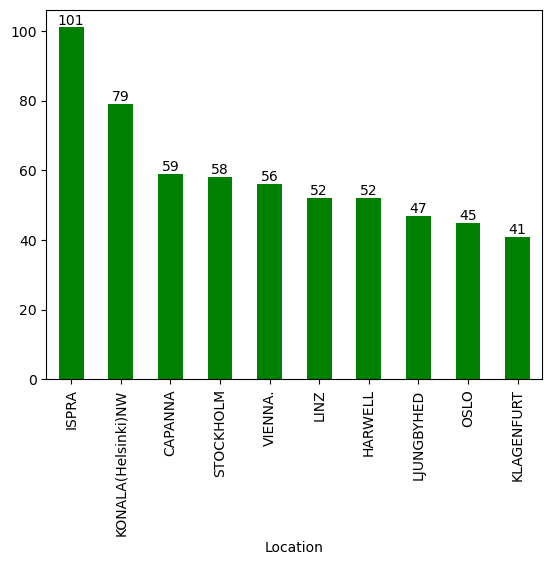

In [74]:
ax1=df['Location'].value_counts().head(10).plot(kind='bar',color='green')
for bars in ax1.containers:
    ax1.bar_label(bars)

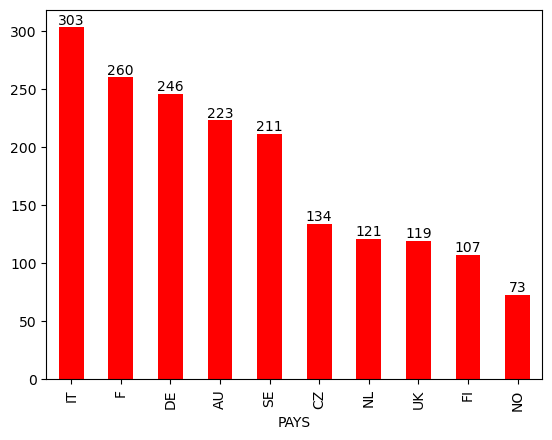

In [76]:
ax1=df['PAYS'].value_counts().head(10).plot(kind='bar',color='red')
for bars in ax1.containers:
    ax1.bar_label(bars)

### A bar chart was created to visualize the top 10 locations with the highest number of radiation measurements. ISPRA recorded the highest number of observations, followed by KÜNW and SAPPANA

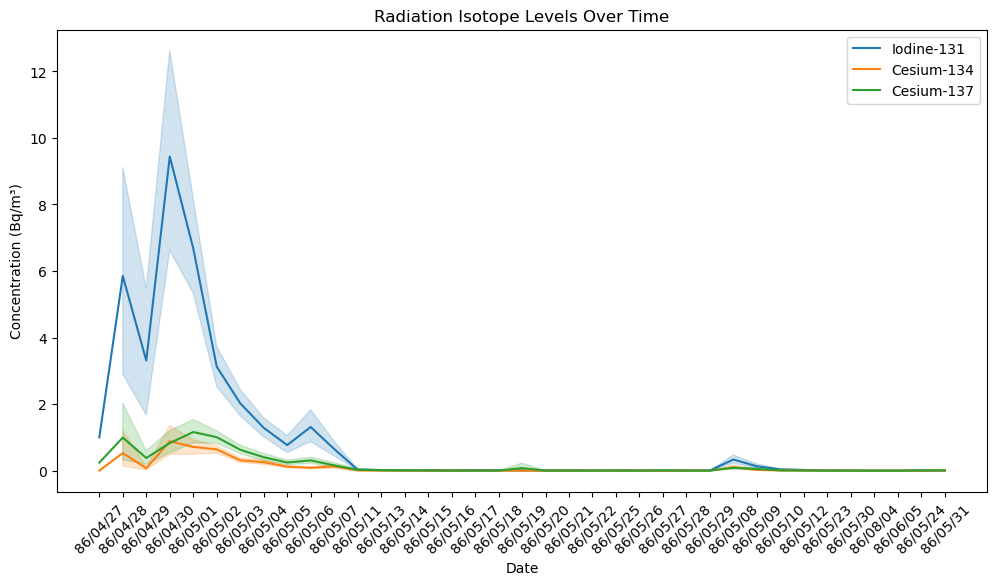

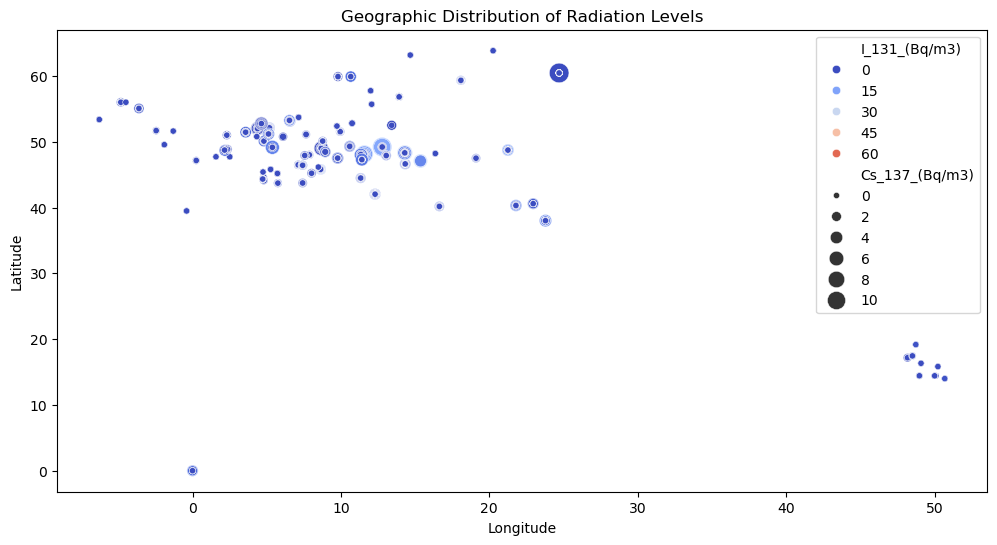

In [83]:


# Inspect the first few rows


# Ensure columns are numeric (sometimes strings slip in)
for col in ["I_131_(Bq/m3)", "Cs_134_(Bq/m3)", "Cs_137_(Bq/m3)"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Example 1: Line plot of isotope levels over time
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="Date", y="I_131_(Bq/m3)", label="Iodine-131")
sns.lineplot(data=df, x="Date", y="Cs_134_(Bq/m3)", label="Cesium-134")
sns.lineplot(data=df, x="Date", y="Cs_137_(Bq/m3)", label="Cesium-137")
plt.xticks(rotation=45)
plt.title("Radiation Isotope Levels Over Time")
plt.ylabel("Concentration (Bq/m³)")
plt.legend()
plt.show()

# Example 2: Scatter plot by location
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x="Longitude", y="Latitude",
                size="Cs_137_(Bq/m3)", hue="I_131_(Bq/m3)",
                palette="coolwarm", sizes=(20,200))
plt.title("Geographic Distribution of Radiation Levels")
plt.show()


### A time-series analysis was performed to examine the variation of radioactive isotope concentrations (I-131, Cs-134, Cs-137) over time.
### The visualization highlights temporal fluctuations in radiation levels, enabling identification of peak contamination periods and decay trends.

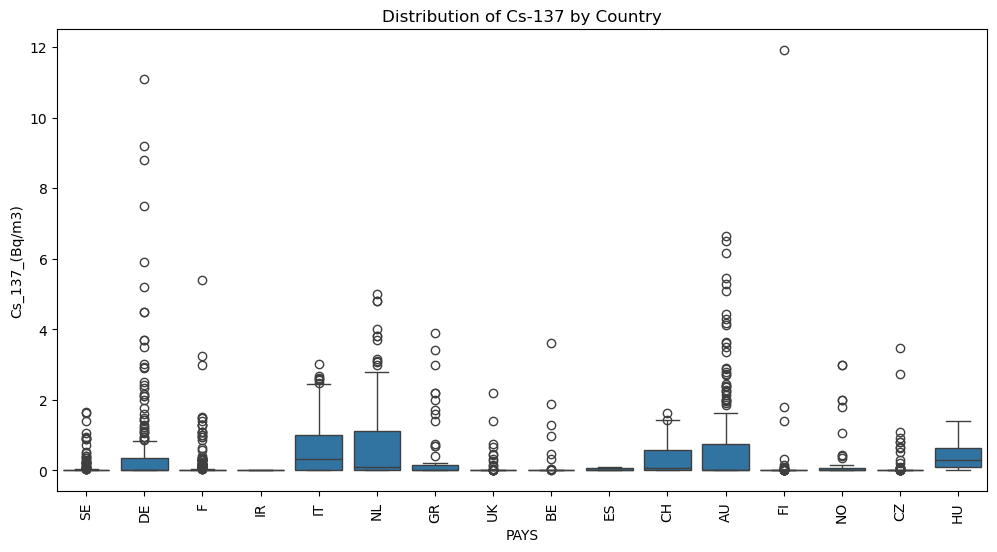

In [86]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="PAYS", y="Cs_137_(Bq/m3)")
plt.xticks(rotation=90)
plt.title("Distribution of Cs-137 by Country")
plt.show()


### boxplot was generated to analyze the distribution of Cs-137 concentration across different countries. The visualization highlights variation and potential outliers in radiation levels.

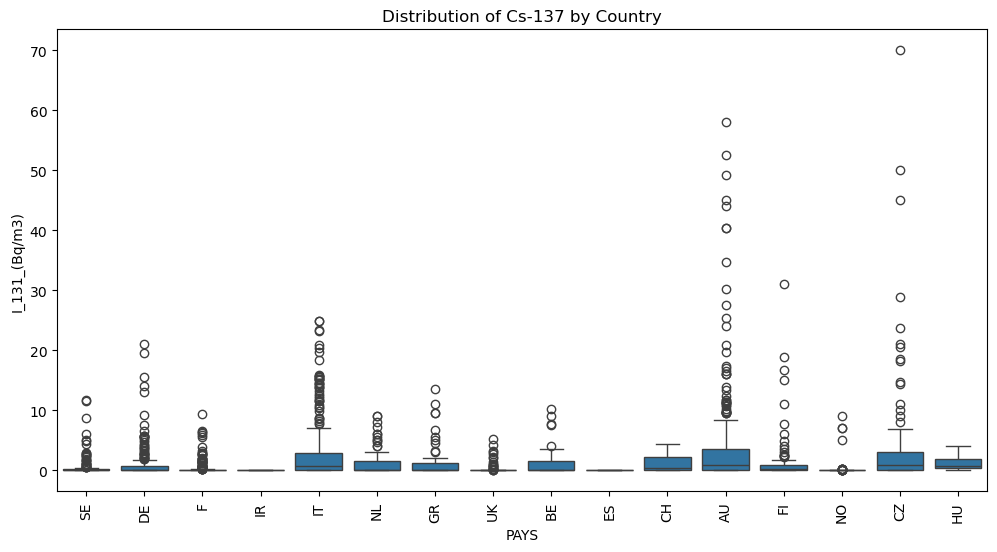

In [88]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="PAYS", y="I_131_(Bq/m3)")
plt.xticks(rotation=90)
plt.title("Distribution of Cs-137 by Country")
plt.show()

### A boxplot was generated to analyze the distribution of I-131 concentration across different countries. The plot highlights differences in median values and variability between countries

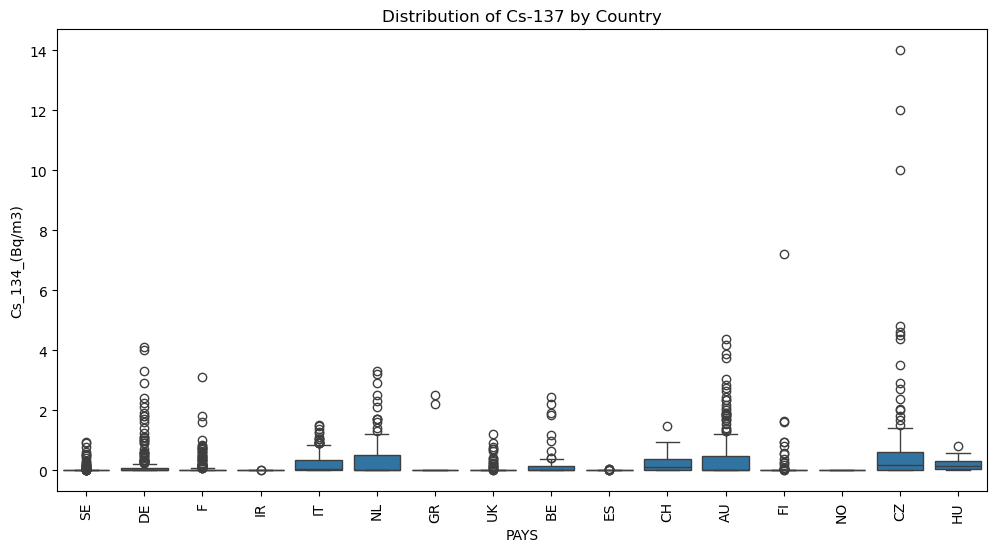

In [87]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="PAYS", y="Cs_134_(Bq/m3)")
plt.xticks(rotation=90)
plt.title("Distribution of Cs-137 by Country")
plt.show()

### A boxplot was generated to analyze the distribution of I-131 concentration across different countries. The plot highlights differences in median values and variability between countries

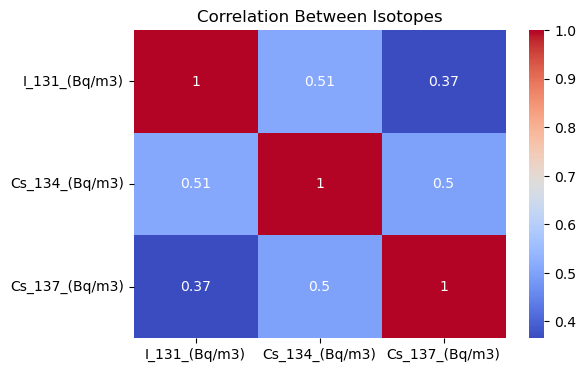

In [89]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["I_131_(Bq/m3)", "Cs_134_(Bq/m3)", "Cs_137_(Bq/m3)"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Between Isotopes")
plt.show()


### A correlation heatmap was generated to analyze the relationship between radioactive isotopes (I-131, Cs-134, Cs-137). The results indicate the strength and direction of linear relationships among these variables.

In [2]:
# This EDA reveals:
#- Sharp short-term spikes in I-131, followed by rapid decline.  
#- Persistent contamination from Cs-134 and Cs-137, with Cs-137 being the most critical long-term pollutant.  
#- Geographic spread across Europe, with higher levels near the accident site.  
#- Strong correlation between cesium isotopes, reflecting similar dispersion patterns.  




## Automated profiling significantly accelerates exploratory analysis and helps identify potential data issues at an early stage

In [7]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title='EDA Report')
profile.to_file('EDA_report.html')


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                            | 0/9 [00:00<?, ?it/s]
100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 42.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]